In [23]:
from importlib import reload
import evosim
reload(evosim); None

In [2]:
%%script echo skipping this cell

args = evosim.default_args.copy()

args.minMu = 2
args.numClades = 3
args.aToB = 0.0

args.s = 0.1 # change this to see effect of selection strength
args.includeMutation = True

args.T = 1e5
args.numEpochs = 1
# BTW runtime is linear in T * numEpochs

args.N = 1e4 # change this and re-run to see differential effect of selection vs drift
args.numRuns = 8
args.numPops = 1

# plotting args
args.plotLog = True
args.plotAB = False
args.plotKFit = True

evosim.evosim(args)

skipping this cell


In [3]:
%%script echo skipping this cell

args, runs = evosim.evosim_run(args)

# plotting args
args.plotLog = True
args.plotAB = False
args.plotFit = True

evosim.evosim_plot(args, runs)

skipping this cell


### Selection:

```python
# As increase by this much more than Bs
freqA = freqA * (1.0 + s)
freqB = freqB * 1.0

# normalize to sum to 1.0
sumFreqs = freqA + freqB
freqA /= sumFreqs
freqB /= sumFreqs

```

---
# Simulations

In [4]:
# Here are all the default arguments.
# Any arguments you add below will override these defaults.

display("default arguments:", evosim.default_args)

'default arguments:'

{'numPops': 1,
 'N': 100000.0,
 'minMu': 2,
 'numClades': 1,
 'aToB': 0.5,
 'T': 1000.0,
 's': 0.1,
 'numEpochs': 1,
 'numRuns': 1,
 'includeMutation': True,
 'stochasticEnv': False,
 'plotLog': False,
 'plotAB': True,
 'plotKFit': False,
 'hideB': False,
 'printStats': False}

---
### Reminder: selection in alternating environments

Ns:100.0 is high >= 10.0 (selection is STRONG relative to drift)
sT:10.0 is low < 20.0 (fixation WON'T usually happen in one epoch)
Using 3 processes for 3 runs.


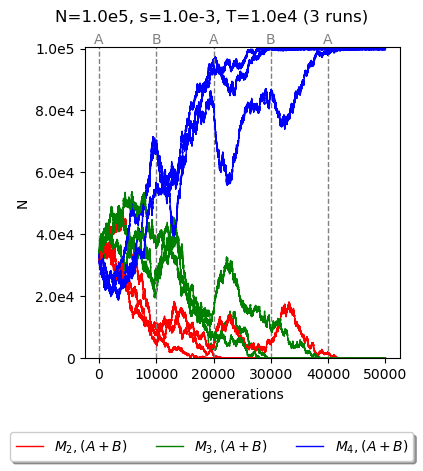

In [5]:
args = evosim.default_args.copy()

args.minMu = 2
args.numClades = 3
args.aToB = 0.0

args.s = 0.001 # change this to see effect of selection strength
args.includeMutation = True

args.T = 1e4
args.numEpochs = 5
# BTW runtime is linear in T * numEpochs

args.N = 1e5 # change this and re-run to see differential effect of selection vs drift

# try args.plotLog = True
# args.plotLog = True
args.plotAB = False
args.numRuns = 3

evosim.evosim(args)

---
### Reminder: long-term selection on different mutators in alternating environments


Infinite population size N (there is no drift)
sT:100.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Note: setting numRuns to 1 because N < 0 (infinite population)


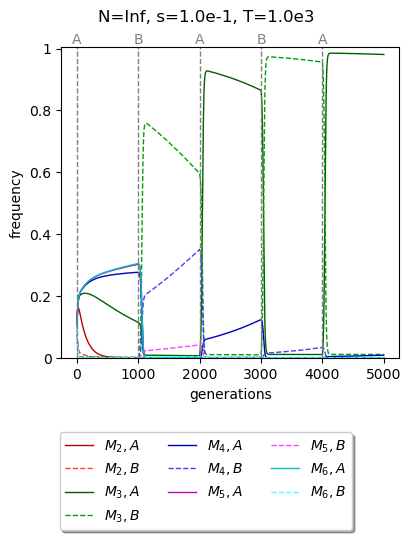

In [6]:
args = evosim.default_args.copy()

args.minMu = 2
args.numClades = 5

args.s = 0.1 # s has to be kept high relative to T, so that sT is not too small
args.includeMutation = True

args.T = 1e3 # try 1e2, 1e3, 1e4, 1e5 - notice that M2, M3, M4, M5 win!
args.numEpochs = 5 # 5

args.N = -1 # change this to finite to see differential effect of selection vs drift

# try: args.plotAB = False to just see individual clades of mutators
# args.plotAB = False

# try args.plotLog = True to see longer term dynamics
# You can also increase args.numEpochs to 10, 20
# args.plotLog = True

evosim.evosim(args)

---
---
### Infinite population case – one epoch, change number of epochs

Infinite population size N (there is no drift)
sT:1000.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Note: setting numRuns to 1 because N < 0 (infinite population)


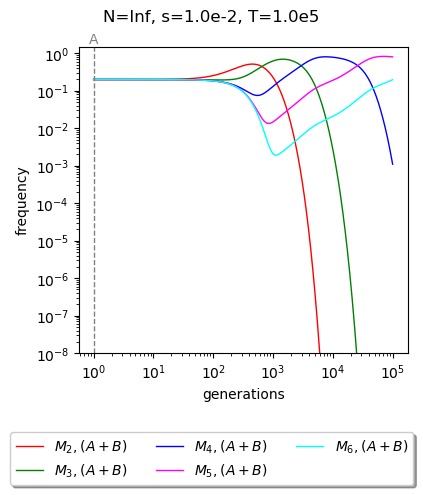

In [7]:
args = evosim.default_args.copy()
args.plotAB = False
args.plotLog = True
args.s = 0.01
args.aToB = 0.0
args.minMu = 2
args.numClades = 5

###

args.T = 1e5
args.numEpochs = 1

args.N = -1 # change this to finite to see differential effect of selection vs drift

evosim.evosim(args)

### The k-fitness, k-survivability and k-surprisal !! – one epoch, change N to 1e6, 1e5, 1e4

Ns:10000.0 is high >= 10.0 (selection is STRONG relative to drift)
sT:2000.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Using 8 processes for 8 runs.


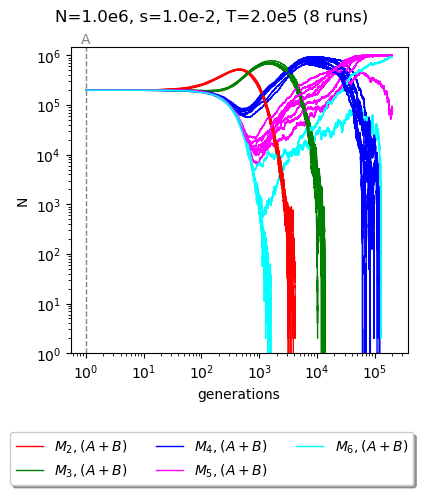

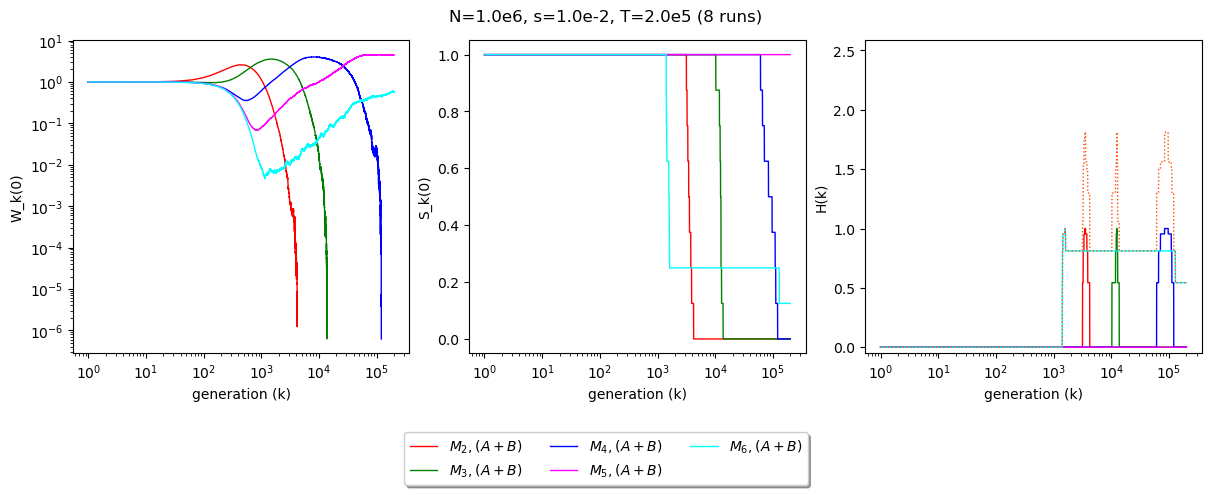

In [24]:
args = evosim.default_args.copy()
args.plotAB = False
args.plotLog = True
args.s = 0.01
args.aToB = 0.0
args.minMu = 2
args.numClades = 5

###

args.numRuns = 8 # increase number of runs to average out stochasticity
args.plotKFit = True # plot k-fitness, k-survivability

args.T = 2e5
args.numEpochs = 1

args.N = 1e6

evosim.evosim(args)

### Entropy

With a set of $n$ possible outcomes of probability $p_i$, their "entropy" is:

$H = - \sum_{i=1}^{n} p_i \log p_i$

<br>When there are only 2 cases A and B, there are only 2 probs $p$ and $q$:

$q = 1-p$

$H = - p \log p - q \log q $


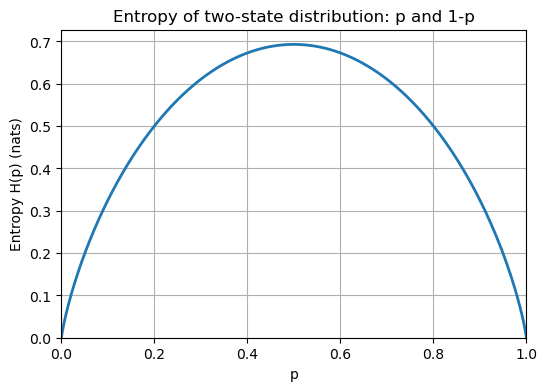

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.0, 1.0, 500)
eps = 1e-12
p_clip = np.clip(p, eps, 1.0 - eps)
H = -p_clip * np.log(p_clip) - (1.0 - p_clip) * np.log1p(-p_clip)

plt.figure(figsize=(6, 4))
plt.plot(p, H, lw=2)
plt.xlabel('p')
plt.ylabel('Entropy H(p) (nats)')
plt.title('Entropy of two-state distribution: p and 1-p')
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0, H.max() * 1.05)
plt.show()

### Surprisal for each clade
In a single replicate, a clade survives or not at each generation $k$: $s(k) =$ {0,1}

(BTW, extinction is permanent.)

Averaged over multiple replicates, each clade $i$ has a prob of survival at generation $k$: $p_i(k)$

So, for the surprisal for each clade at generation $k$, $H_i(k)$ we compute:

$q_i(k) = 1-p_i(k)$

$H_i(k) = - p_i(k) \log p_i(k) - q_i(k) \log q_i(k) $

### Joint surprisal
For the joint surprisal:

In a single replicate, a clade survives, or not: {0,1} at each generation k

Averaged over replicates, each clade 

There are $2^{numClades}$ states of the whole population. For 3 clades there are 8 states:
```python
(0, 0, 0)
(0, 0, 1)
(0, 1, 0)
(0, 1, 1)
(1, 0, 0)
(1, 0, 1)
(1, 1, 0)
(1, 1, 1)
```

Each of these 8 states $i$ has a $p_i(k)$ at each time $k$, depending on which sets of clades survived, or went extinct.

So at time $t$ we can compute the entropy – the "joint surprisal" over these 8 states:

$H^{joint}(k) = -\sum_{i=1}^{8} p_i(k) \log p_i(k)$

Some constraints on $H_{joint}(k)$:

$H_{joint}(k) \geq \max_i H^i(k)$

### Effect of epoch length – multiple epochs, change T to 1e5, 1e4, 1e3

Ns:10000.0 is high >= 10.0 (selection is STRONG relative to drift)
sT:100.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Using 8 processes for 8 runs.


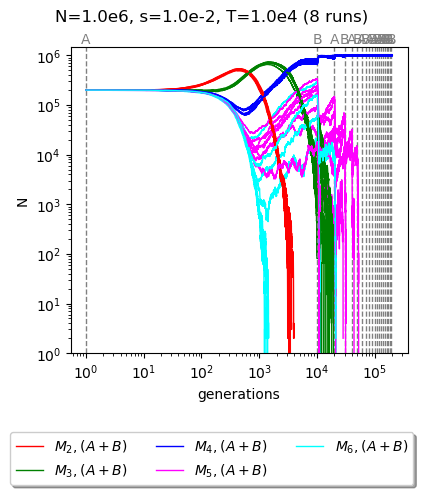

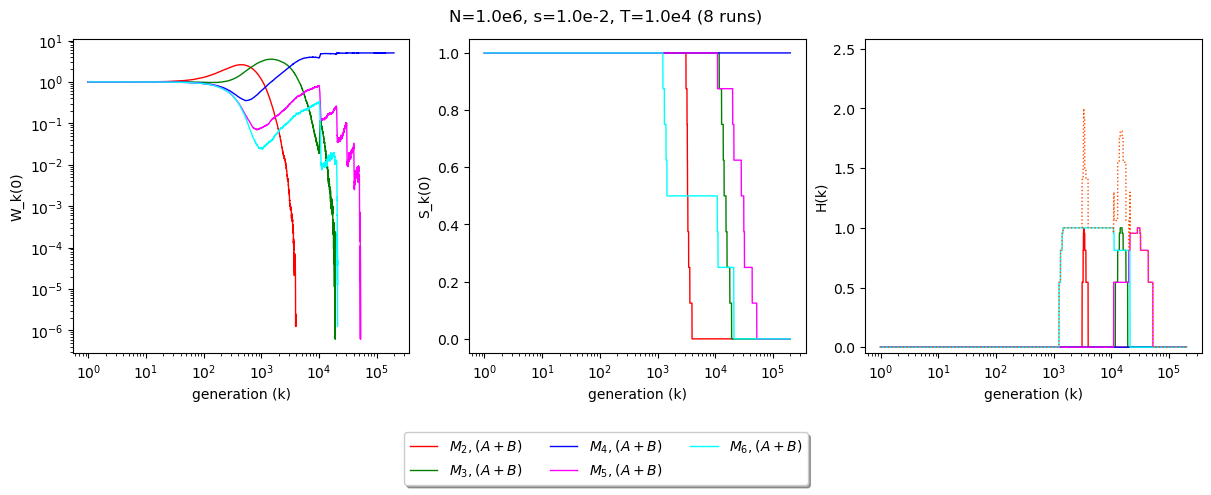

In [10]:
args = evosim.default_args.copy()
args.plotAB = False
args.plotLog = True
args.aToB = 0.0
args.minMu = 2
args.numClades = 5

###

args.numRuns = 8 # increase number of runs to average out stochasticity
args.plotKFit = True # plot k-fitness, k-survivability and k-surprisal

totalT = 2e5 # total time
args.T = 1e4 # epoch length
args.numEpochs = totalT/args.T # multiple epochs

args.s = 0.01 # can also tweak s to cause more surprisal
args.N = 1e6

evosim.evosim(args)

### Migration mode (just run this one as is)

Ns:10000.0 is high >= 10.0 (selection is STRONG relative to drift)
sT:100.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Running in MIGRATION mode with 2 populations
Using 8 processes for 8 runs.


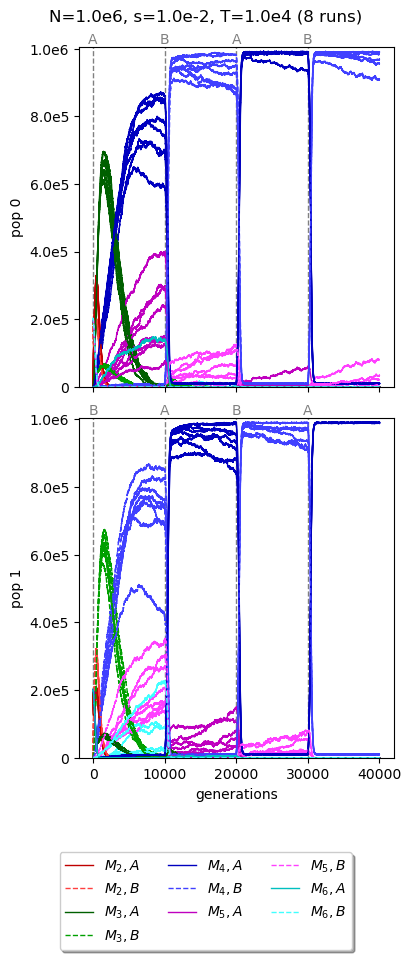

In [11]:
args = evosim.default_args.copy()
args.plotLog = False
args.s = 0.01
args.aToB = 0.0
args.minMu = 2
args.numClades = 5

###

args.plotAB = True
args.plotKFit = False

args.numRuns = 8 # increase number of runs to average out stochasticity

args.T = 1e4 # epoch length
args.numEpochs = 4 # multiple epochs

args.numPops = 2 # 2 populations -> automatically switches to MIGRATION mode. There's NO mutation!

args.N = 1e6

evosim.evosim(args)

### Migration – 2 pops, change T to 1e5, 1e4, 1e3

Ns:10000.0 is high >= 10.0 (selection is STRONG relative to drift)
sT:100.0 is high >= 20.0 (fixation CAN happen in one epoch (ignoring mutation))
Running in MIGRATION mode with 2 populations
Using 8 processes for 8 runs.


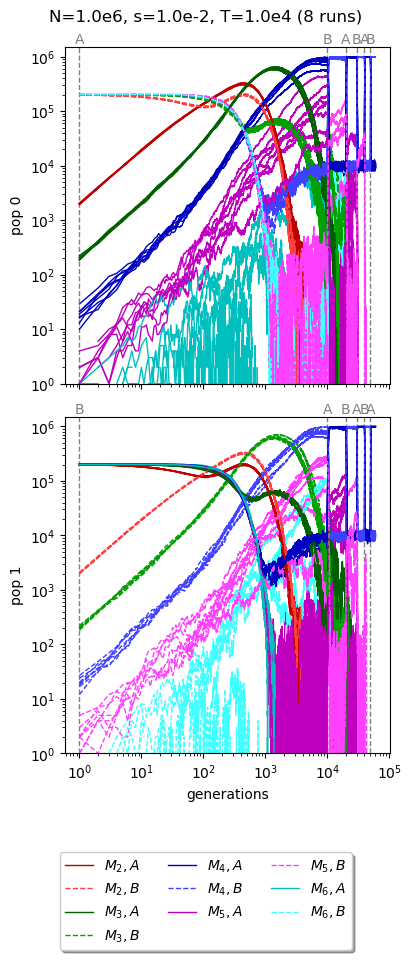

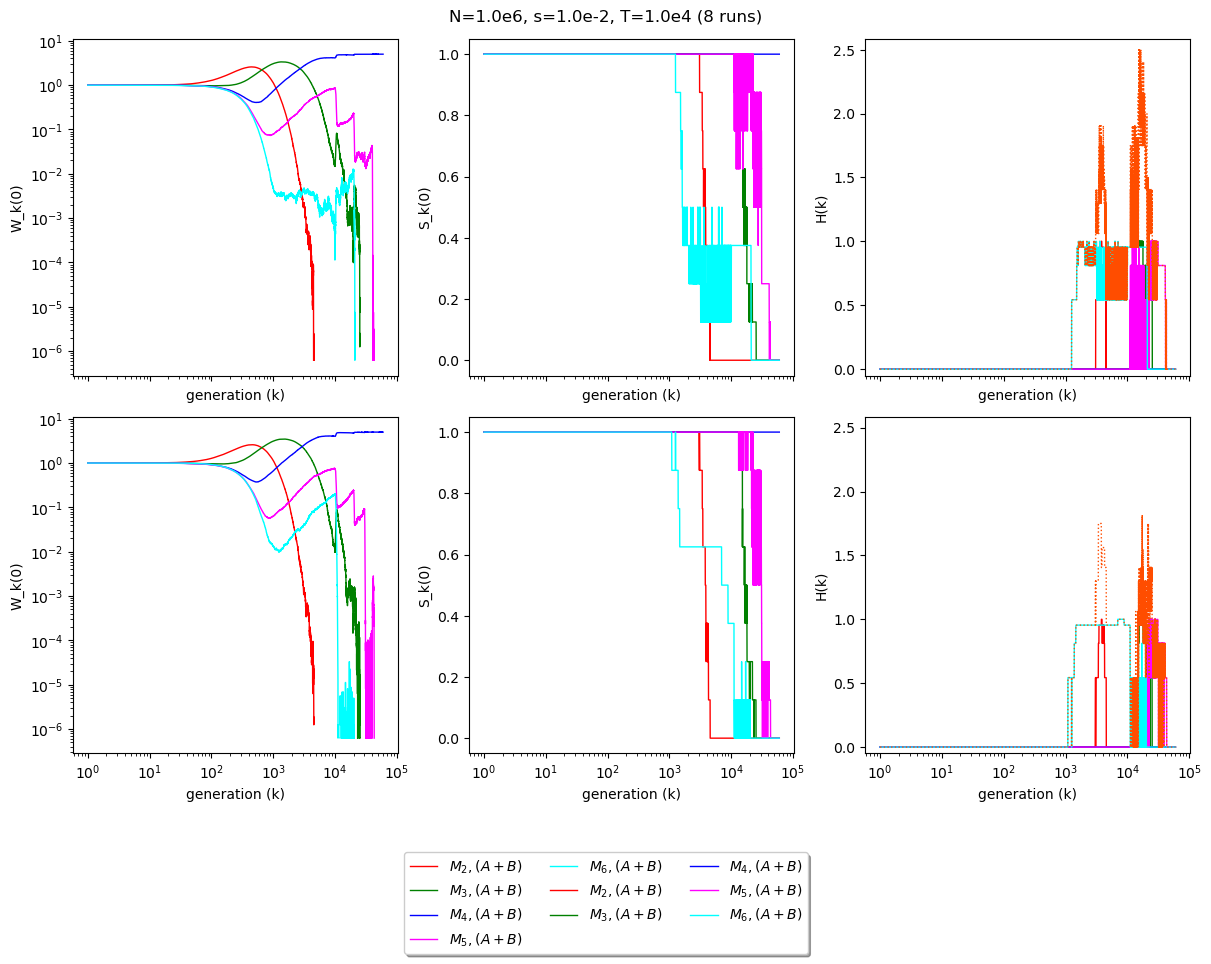

In [12]:
args = evosim.default_args.copy()
args.plotLog = True
args.s = 0.01
args.aToB = 0.0
args.minMu = 2
args.numClades = 5

###

args.plotAB = True

args.numRuns = 8 # increase number of runs to average out stochasticity
args.plotKFit = True # plot k-fitness, k-survivability and k-surprisal

args.T = 1e4 # epoch length
args.numEpochs = 6 # multiple epochs

args.numPops = 2 # 2 populations -> automatically switches to MIGRATION mode. There's NO mutation!

args.N = 1e6

evosim.evosim(args)

### Stochastic environments – infinite pop

Infinite population size N (there is no drift)
sT:10.0 is low < 20.0 (fixation WON'T usually happen in one epoch)
Note: setting numRuns to 1 because N < 0 (infinite population)


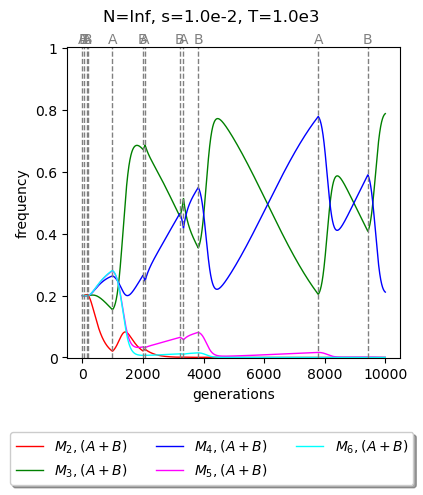

In [ ]:
args = evosim.default_args.copy()

args.minMu = 2
args.numClades = 5

args.s = 0.01 # change this to see effect of selection strength
args.includeMutation = True
args.T = 1e3
args.numEpochs = 10
args.stochasticEnv = True

args.N = -1 # change this and re-run to see differential effect of selection vs drift
args.plotAB = False
#args.plotLog = True

evosim.evosim(args)

### Stochastic environments  – finite pop

Ns:100.0 is high >= 10.0 (selection is STRONG relative to drift)
sT:10.0 is low < 20.0 (fixation WON'T usually happen in one epoch)


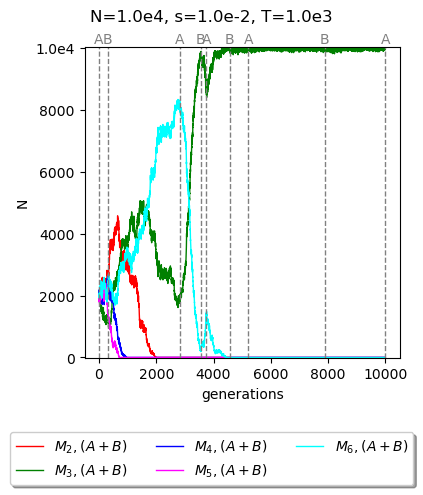

In [61]:
args = evosim.default_args.copy()

args.minMu = 2
args.numClades = 5

args.s = 0.01 # change this to see effect of selection strength
args.includeMutation = True
args.T = 1e3
args.numEpochs = 10
args.stochasticEnv = True

args.N = 1e4 # change this and re-run to see differential effect of selection vs drift
args.plotAB = False
#args.plotLog = True

evosim.evosim(args)

### Stochastic environments  – finite pop, and multiple runs. Try setting plotKFit = True

Ns:100.0 is high >= 10.0 (selection is STRONG relative to drift)
sT:10.0 is low < 20.0 (fixation WON'T usually happen in one epoch)
Using 8 processes for 8 runs.


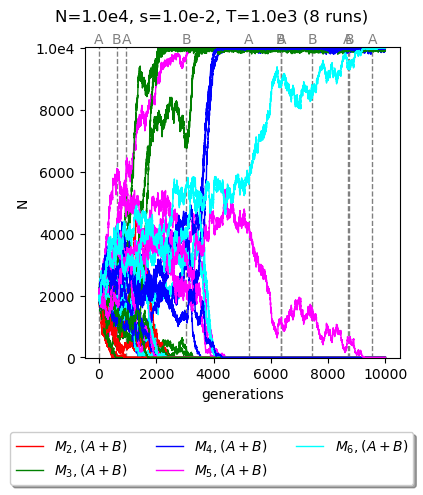

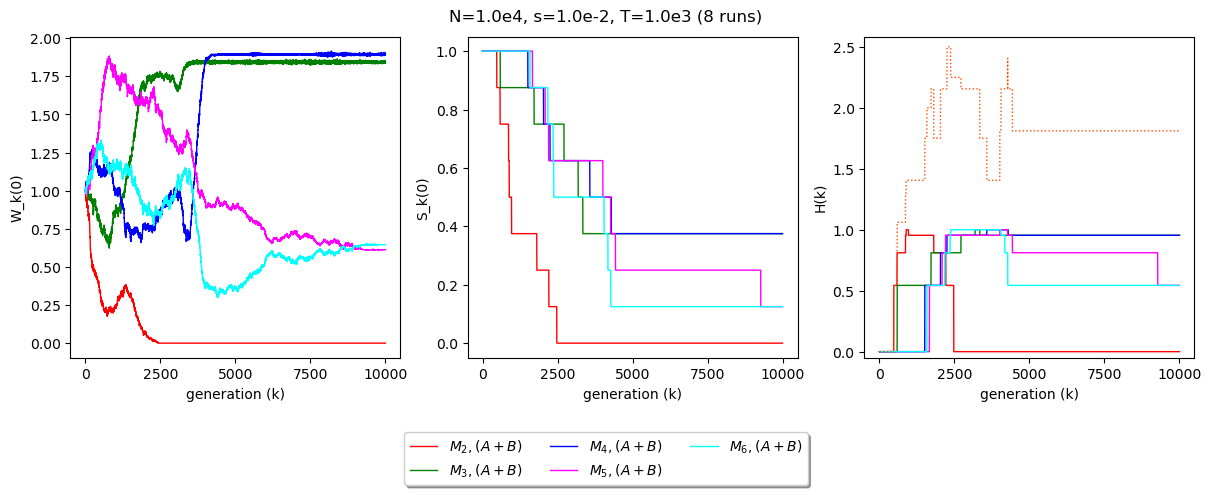

In [65]:
#%%script echo skipping

args = evosim.default_args.copy()

args.minMu = 2
args.numClades = 5

args.s = 0.01 # change this to see effect of selection strength
args.includeMutation = True
args.T = 1e3
args.numEpochs = 10
args.stochasticEnv = True

args.N = 1e4 # change this and re-run to see differential effect of selection vs drift
args.plotAB = False
#args.plotLog = True

args.numRuns = 8 # increase number of runs to average out stochasticity
args.plotKFit = True # plot k-fitness, k-survivability and k-surprisal

evosim.evosim(args)